# Chapter 02: Regular Surfaces

Source orientation: printed pp. 53-135; PDF pp. 69-151. The source span covers Chapter 2, Sections 2-1 through 2-8, plus the chapter appendix on continuity, differentiability, differentials, chain rule, and inverse function theorem. This notebook is original teaching material: it uses the source only for terminology and order of ideas, and it does not reproduce textbook prose, figures, exercise text, hints, or answers.

## Chapter Goal

Build the computational meaning of a regular surface: certify local patches, recognize implicit regular values, move safely between coordinates, construct tangent planes and differentials, measure with the first fundamental form, compute area, and diagnose orientation as a global compatibility problem.


## Computational Translation Guide

| Book idea | Computational object | What the check should prove |
| --- | --- | --- |
| Coordinate patch `x(u,v)` | A map with two sampled or symbolic partial derivatives | `x_u` and `x_v` are independent, so `||x_u cross x_v|| > 0` locally |
| Inverse image of a regular value | A level surface `f(x,y,z)=a` with gradient samples | `grad f` is nonzero along the level, and it supplies the normal direction |
| Coordinate change | A map between parameter planes on chart overlap | Its Jacobian determinant is nonzero on the overlap |
| Tangent plane | Span of patch partials or velocities of surface curves | Curve velocities lie in the same plane and are orthogonal to an implicit normal |
| Differential of a map | Linear pushforward on tangent vectors | Tangency, linearity, and chain-rule behavior survive the map |
| First fundamental form | Metric matrix `[[E,F],[F,G]]` | It is positive definite and `EG-F^2 = ||x_u cross x_v||^2` |
| Area | Integral of `sqrt(EG-F^2)` | Mesh or quadrature estimates converge to the same quantity |
| Orientation | Compatible chart signs or a global unit normal field | Normal choices can be transported coherently, or they flip after a loop |

The chapter is mostly local until orientation. The central habit is to ask for a certificate: rank, gradient, Jacobian, metric determinant, or normal compatibility.


In [1]:
from pathlib import Path
import csv
import json
import math
import sys

import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import sympy as sp
import trimesh
from IPython.display import IFrame, Image, display


def find_book_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / '00-book-index.ipynb').exists() and (candidate / 'utils').exists():
            return candidate
    for candidate in candidates:
        book = candidate / 'Differential-Geometry-of-Curves-and-Surfaces'
        if (book / '00-book-index.ipynb').exists() and (book / 'utils').exists():
            return book
    raise RuntimeError('Could not locate the course root')


BOOK_ROOT = find_book_root()
CHAPTER_DIR = BOOK_ROOT / 'chapter-02-regular-surfaces'
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifact, display_artifact, write_json
from utils.plotting import COURSE_COLORS, equalize_3d_axes, finish_axes, set_course_style

set_course_style()
UNIT = 'chapter-02'
ARTIFACT_BASE = BOOK_ROOT / 'artifacts' / UNIT
FIG_DIR = ARTIFACT_BASE / 'figures'
HTML_DIR = ARTIFACT_BASE / 'interactive'
CHECK_DIR = ARTIFACT_BASE / 'checks'
TABLE_DIR = ARTIFACT_BASE / 'tables'
for folder in [FIG_DIR, HTML_DIR, CHECK_DIR, TABLE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

SOURCE_SPAN = {
    'printed_pages': '53-135',
    'pdf_pages': '69-151',
    'source_map': 'pdf_page = printed_page + 16',
    'sections': ['2-1 introduction', '2-2 regular surfaces and regular values', '2-3 chart changes and differentiable functions', '2-4 tangent planes and differentials', '2-5 first fundamental form and area', '2-6 orientation', '2-7 compact orientable surfaces', '2-8 geometric area', 'appendix: continuity and differentiability'],
}

PATHS = {}
CHECKS = {'source_span': SOURCE_SPAN}


def rel(path):
    return Path(path).resolve().relative_to(BOOK_ROOT).as_posix()


def register(name, path):
    PATHS[name] = rel(path)
    return path


def save_fig(name, filename, fig, dpi=170):
    path = FIG_DIR / filename
    fig.savefig(path, dpi=dpi, bbox_inches='tight')
    register(name, path)
    return path


def save_html(name, filename, fig):
    path = HTML_DIR / filename
    fig.write_html(path, include_plotlyjs='cdn', full_html=True)
    register(name, path)
    return path


def save_check(name, filename, data):
    path = write_json(data, UNIT, 'checks', filename, root=BOOK_ROOT / 'artifacts')
    register(name, path)
    return path


def display_png(name, width=760):
    display_artifact(BOOK_ROOT / PATHS[name], width=width)


def display_html(name, width='100%', height=560):
    src = '../' + PATHS[name]
    display(IFrame(src=src, width=width, height=height))


def norm_rows(array):
    return np.linalg.norm(array, axis=-1)


## Visual Storyboard

The notebook replaces the generic builder with chapter-specific cells. Each artifact has an inspection target and a numerical or symbolic invariant.


In [2]:
STORYBOARD = [
    {
        'item': 'patch rank versus cone failure',
        'representation': 'Matplotlib 3D static diagnostic',
        'artifact': 'figures/regularity-rank-certificates.png',
        'inspection_target': 'the graph patch keeps a nonzero cross product; the cone parametrization collapses at the apex',
        'check': 'min graph cross-norm is positive, cone apex cross-norm is zero',
    },
    {
        'item': 'regular value level surface',
        'representation': 'Plotly 3D ellipsoid mesh with gradient cones',
        'artifact': 'interactive/regular-value-ellipsoid-gradient.html',
        'inspection_target': 'the gradient is never zero on the sampled level and is normal to the surface',
        'check': 'sampled gradient norms have a positive lower bound',
    },
    {
        'item': 'coordinate change on an overlap',
        'representation': 'SymPy Jacobian plus Matplotlib grid inversion',
        'artifact': 'figures/stereographic-coordinate-change.png',
        'inspection_target': 'grid cells distort but the transition remains locally invertible away from the missing point',
        'check': 'Jacobian determinant is nonzero on the overlap samples',
    },
    {
        'item': 'tangent plane and differential',
        'representation': 'Plotly sphere with tangent vector before and after a rotation map',
        'artifact': 'interactive/tangent-plane-differential-rotation.html',
        'inspection_target': 'the pushed vector remains tangent at the image point and keeps its length',
        'check': 'orthogonality and norm residuals are below tolerance',
    },
    {
        'item': 'first fundamental form on a helicoid',
        'representation': 'SymPy identity and metric ellipses',
        'artifact': 'figures/first-fundamental-form-helicoid-ellipses.png',
        'inspection_target': 'the metric ellipse narrows in the direction with larger surface stretch',
        'check': 'symbolically, EG-F^2 equals squared cross-product norm',
    },
    {
        'item': 'area density and mesh convergence',
        'representation': 'Plotly helicoid density and Trimesh torus area refinement',
        'artifact': 'figures/torus-area-mesh-refinement.png',
        'inspection_target': 'area is a metric determinant, not a picture-area guess',
        'check': 'mesh area approaches 4*pi^2*R*r and the torus mesh has Euler characteristic zero',
    },
    {
        'item': 'orientation as a global compatibility test',
        'representation': '3D normal fields on a torus and an open Mobius band',
        'artifact': 'figures/orientation-normal-coherence.png',
        'inspection_target': 'torus normals return coherently while the Mobius centerline normal flips after one circuit',
        'check': 'torus normal agreement is positive; Mobius transported normal has dot product near -1',
    },
]
CHECKS['storyboard_items'] = len(STORYBOARD)
save_check('visual_storyboard', 'visual-storyboard.json', {'source_span': SOURCE_SPAN, 'items': STORYBOARD})
PATHS['visual_storyboard']


'artifacts/chapter-02/checks/visual-storyboard.json'

## 1. Regular Surface Certificates: Patch Rank and Regular Values

A surface patch is not certified by looking smooth in a drawing. The local certificate is the rank of the derivative. For a patch `x(u,v)`, the two coordinate partials must span a plane; in `R^3`, this is the same as requiring `x_u cross x_v` to be nonzero.

The graph patch below has a built-in rank certificate because the cross product always has third component `1`. The cone parametrization shows the opposite failure mode: away from the apex the cross product is nonzero, but at the apex the parametrization loses rank and the underlying set does not have one tangent plane there.


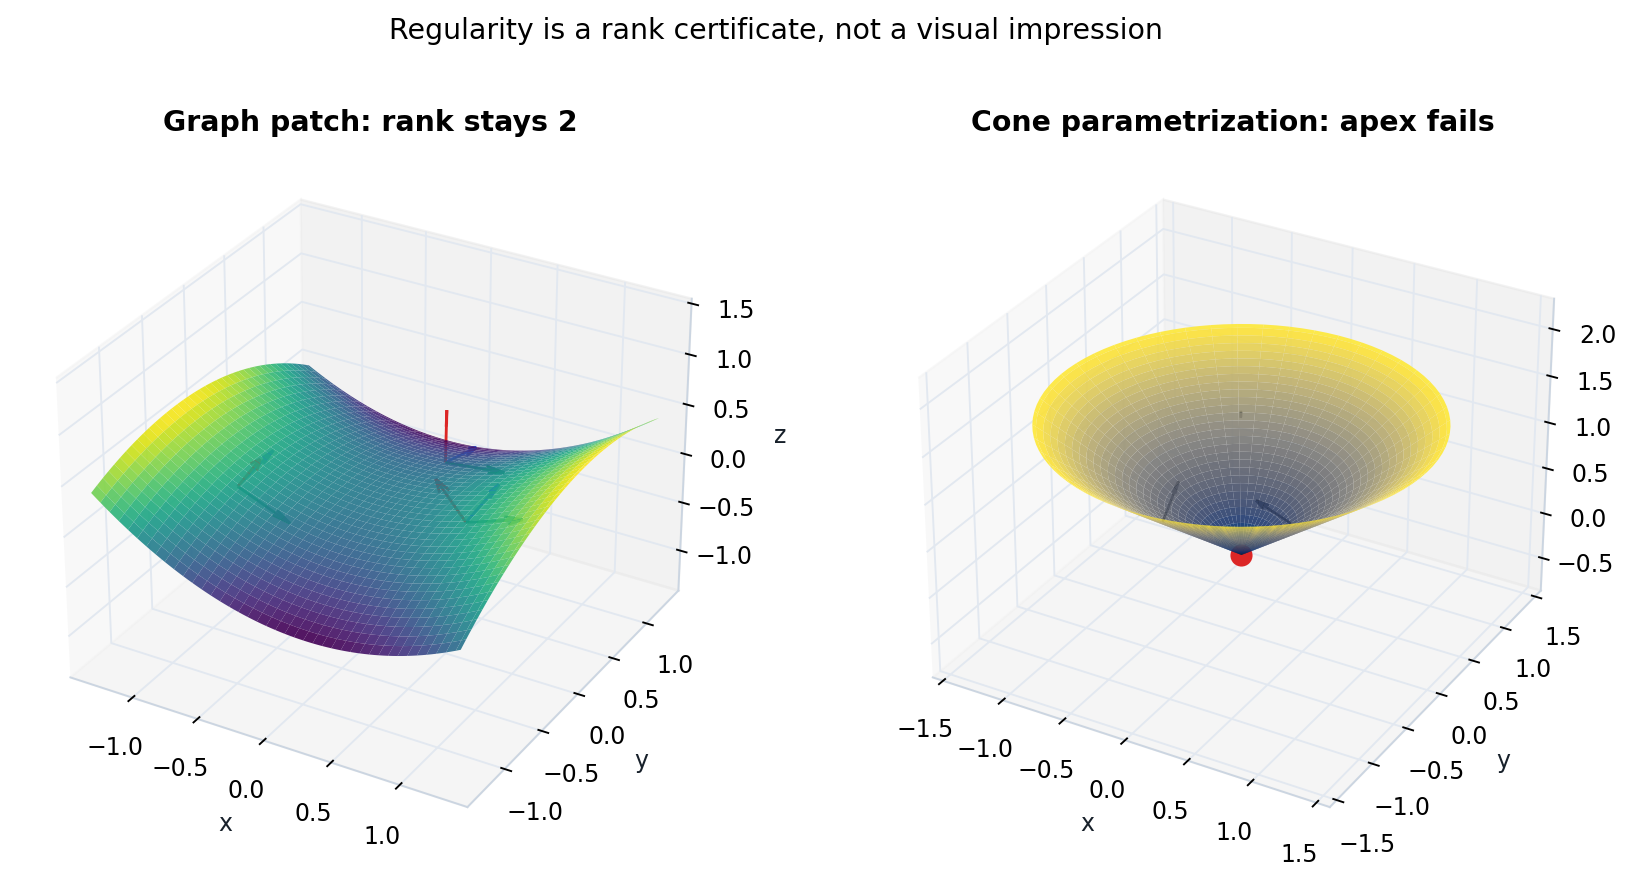

In [3]:
def graph_surface(u, v):
    z = 0.32 * u * u - 0.22 * v * v + 0.12 * u * v
    return np.stack([u, v, z], axis=-1)


def graph_partials(u, v):
    fu = 0.64 * u + 0.12 * v
    fv = -0.44 * v + 0.12 * u
    xu = np.stack([np.ones_like(u), np.zeros_like(u), fu], axis=-1)
    xv = np.stack([np.zeros_like(u), np.ones_like(u), fv], axis=-1)
    return xu, xv


def cone_surface(r, theta):
    return np.stack([r * np.cos(theta), r * np.sin(theta), r], axis=-1)


def cone_partials(r, theta):
    xr = np.stack([np.cos(theta), np.sin(theta), np.ones_like(theta)], axis=-1)
    xt = np.stack([-r * np.sin(theta), r * np.cos(theta), np.zeros_like(theta)], axis=-1)
    return xr, xt

u = np.linspace(-1.35, 1.35, 80)
v = np.linspace(-1.35, 1.35, 80)
U, V = np.meshgrid(u, v, indexing='ij')
G = graph_surface(U, V)
Gu, Gv = graph_partials(U, V)
graph_cross = np.cross(Gu, Gv)
graph_cross_norm = norm_rows(graph_cross)

theta = np.linspace(0.0, 2.0 * np.pi, 96)
r = np.linspace(0.0, 1.45, 60)
R, T = np.meshgrid(r, theta, indexing='ij')
C = cone_surface(R, T)
Cr, Ct = cone_partials(R, T)
cone_cross_norm = norm_rows(np.cross(Cr, Ct))

fig = plt.figure(figsize=(12, 5.4))
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(G[..., 0], G[..., 1], G[..., 2], cmap='viridis', linewidth=0, antialiased=True, alpha=0.92)
for ui, vi in [(-0.75, -0.55), (0.1, 0.7), (0.75, -0.2)]:
    p = graph_surface(np.array(ui), np.array(vi))
    xu, xv = graph_partials(np.array(ui), np.array(vi))
    normal = np.cross(xu, xv)
    normal = normal / np.linalg.norm(normal)
    ax1.quiver(*p, *(0.45 * xu / np.linalg.norm(xu)), color=COURSE_COLORS['green'], linewidth=1.2)
    ax1.quiver(*p, *(0.45 * xv / np.linalg.norm(xv)), color=COURSE_COLORS['blue'], linewidth=1.2)
    ax1.quiver(*p, *(0.45 * normal), color=COURSE_COLORS['red'], linewidth=1.2)
ax1.set_title('Graph patch: rank stays 2')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')
equalize_3d_axes(ax1, G[..., 0].ravel(), G[..., 1].ravel(), G[..., 2].ravel())

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(C[..., 0], C[..., 1], C[..., 2], cmap='cividis', linewidth=0, antialiased=True, alpha=0.9)
ax2.scatter([0], [0], [0], s=70, color=COURSE_COLORS['red'], label='rank collapse')
for ri, ti in [(0.35, 0.5), (0.85, 2.1), (1.25, 4.8)]:
    p = cone_surface(np.array(ri), np.array(ti))
    xr, xt = cone_partials(np.array(ri), np.array(ti))
    normal = np.cross(xr, xt)
    normal = normal / np.linalg.norm(normal)
    ax2.quiver(*p, *(0.35 * normal), color=COURSE_COLORS['ink'], linewidth=1.1)
ax2.set_title('Cone parametrization: apex fails')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('z')
equalize_3d_axes(ax2, C[..., 0].ravel(), C[..., 1].ravel(), C[..., 2].ravel())
fig.suptitle('Regularity is a rank certificate, not a visual impression', y=1.02)
save_fig('regularity_rank', 'regularity-rank-certificates.png', fig)
plt.close(fig)

regularity_checks = {
    'graph_cross_norm_min': float(graph_cross_norm.min()),
    'graph_cross_norm_max': float(graph_cross_norm.max()),
    'cone_cross_norm_at_apex': float(cone_cross_norm[0, 0]),
    'cone_cross_norm_min_away_from_apex_r_ge_0_2': float(cone_cross_norm[R >= 0.2].min()),
}
assert regularity_checks['graph_cross_norm_min'] > 0.99
assert regularity_checks['cone_cross_norm_at_apex'] == 0.0
assert regularity_checks['cone_cross_norm_min_away_from_apex_r_ge_0_2'] > 0.25
CHECKS['regularity'] = regularity_checks
save_check('regularity_checks', 'regularity-rank-checks.json', regularity_checks)
display_png('regularity_rank')


A regular value gives a second certificate. If `S = f^{-1}(a)` and `grad f` is nonzero along `S`, the gradient is a normal witness and the implicit function theorem supplies local patches. The ellipsoid is shown as a mesh so the level-set idea is connected to a concrete surface that can be rotated.


In [4]:
def ellipsoid_mesh(a=1.45, b=1.0, c=0.72, nu=80, nv=40):
    u = np.linspace(0.0, 2.0 * np.pi, nu, endpoint=False)
    v = np.linspace(0.0, np.pi, nv)
    U, V = np.meshgrid(u, v, indexing='ij')
    X = a * np.sin(V) * np.cos(U)
    Y = b * np.sin(V) * np.sin(U)
    Z = c * np.cos(V)
    vertices = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])
    faces = []
    for i in range(nu):
        ni = (i + 1) % nu
        for j in range(nv - 1):
            p00 = i * nv + j
            p10 = ni * nv + j
            p11 = ni * nv + j + 1
            p01 = i * nv + j + 1
            faces.append([p00, p10, p11])
            faces.append([p00, p11, p01])
    return U, V, vertices, np.asarray(faces, dtype=int)


def ellipsoid_gradient(points, a=1.45, b=1.0, c=0.72):
    x, y, z = points[:, 0], points[:, 1], points[:, 2]
    return np.column_stack([2 * x / (a * a), 2 * y / (b * b), 2 * z / (c * c)])

Ue, Ve, ell_vertices, ell_faces = ellipsoid_mesh()
ell_grad = ellipsoid_gradient(ell_vertices)
ell_grad_norm = norm_rows(ell_grad)

sample_params = [(0.30, 0.70), (1.80, 1.25), (3.70, 1.00), (5.10, 2.25)]
cone_x = []
cone_y = []
cone_z = []
cone_u = []
cone_v = []
cone_w = []
for us, vs in sample_params:
    p = np.array([1.45 * np.sin(vs) * np.cos(us), 1.0 * np.sin(vs) * np.sin(us), 0.72 * np.cos(vs)])
    g = ellipsoid_gradient(p.reshape(1, 3))[0]
    g = g / np.linalg.norm(g)
    cone_x.append(p[0]); cone_y.append(p[1]); cone_z.append(p[2])
    cone_u.append(g[0]); cone_v.append(g[1]); cone_w.append(g[2])

fig = go.Figure()
fig.add_trace(go.Mesh3d(
    x=ell_vertices[:, 0], y=ell_vertices[:, 1], z=ell_vertices[:, 2],
    i=ell_faces[:, 0], j=ell_faces[:, 1], k=ell_faces[:, 2],
    intensity=ell_grad_norm,
    colorscale='Viridis', opacity=0.82, showscale=True,
    colorbar={'title': '||grad f||'}, name='regular level mesh'))
fig.add_trace(go.Cone(
    x=cone_x, y=cone_y, z=cone_z, u=cone_u, v=cone_v, w=cone_w,
    sizemode='absolute', sizeref=0.28, anchor='tail', showscale=False,
    colorscale=[[0, COURSE_COLORS['red']], [1, COURSE_COLORS['red']]], name='gradient normals'))
fig.update_layout(
    title='Regular value certificate: ellipsoid level with nonzero gradient normals',
    scene={'aspectmode': 'data', 'xaxis_title': 'x', 'yaxis_title': 'y', 'zaxis_title': 'z'},
    margin={'l': 0, 'r': 0, 't': 48, 'b': 0})
save_html('regular_value_ellipsoid', 'regular-value-ellipsoid-gradient.html', fig)

regular_value_checks = {
    'ellipsoid_sample_count': int(len(ell_vertices)),
    'gradient_norm_min': float(ell_grad_norm.min()),
    'gradient_norm_max': float(ell_grad_norm.max()),
    'mesh_face_count': int(len(ell_faces)),
}
assert regular_value_checks['gradient_norm_min'] > 1.35
CHECKS['regular_value'] = regular_value_checks
save_check('regular_value_checks', 'regular-value-gradient-checks.json', regular_value_checks)
display_html('regular_value_ellipsoid')


## 2. Coordinate Changes and Functions on Surfaces

A function on a surface is differentiable only if the definition is independent of the chart used to inspect it. That is why chart transitions matter: on an overlap, the transition map must be differentiable with a nonsingular Jacobian.

For the sphere, stereographic coordinates from opposite poles lead to an inversion-type transition on the overlap. The grid below is not meant to imitate a book figure; it is a computational microscope for the Jacobian condition. Lines bend and scale, but every sampled cell away from the missing point remains locally invertible.


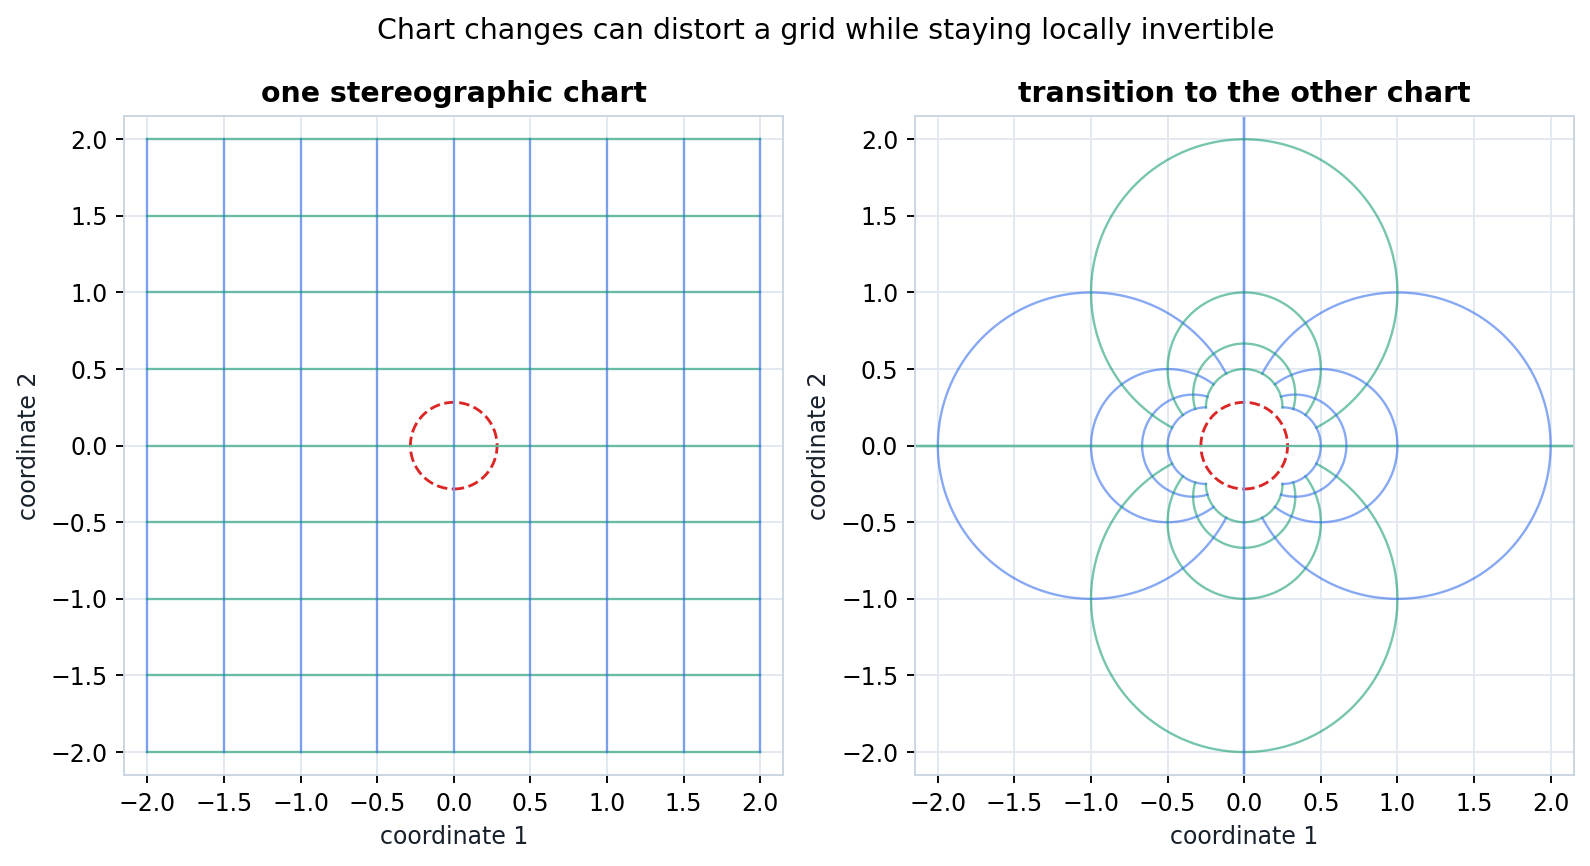

In [5]:
u_sym, v_sym = sp.symbols('u v', real=True)
r2 = u_sym**2 + v_sym**2
transition = sp.Matrix([u_sym / r2, v_sym / r2])
J_transition = transition.jacobian([u_sym, v_sym])
det_transition = sp.simplify(J_transition.det())
expected_det = -1 / r2**2
assert sp.simplify(det_transition - expected_det) == 0

fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))
levels = np.linspace(-2.0, 2.0, 9)
line = np.linspace(-2.0, 2.0, 400)

def inv_xy(x, y):
    denom = x * x + y * y
    return x / denom, y / denom

for value in levels:
    x = np.full_like(line, value)
    y = line.copy()
    mask = x * x + y * y > 0.08
    axes[0].plot(x[mask], y[mask], color=COURSE_COLORS['blue'], alpha=0.55, lw=1.0)
    xi, yi = inv_xy(x[mask], y[mask])
    axes[1].plot(xi, yi, color=COURSE_COLORS['blue'], alpha=0.55, lw=1.0)

    x = line.copy()
    y = np.full_like(line, value)
    mask = x * x + y * y > 0.08
    axes[0].plot(x[mask], y[mask], color=COURSE_COLORS['green'], alpha=0.55, lw=1.0)
    xi, yi = inv_xy(x[mask], y[mask])
    axes[1].plot(xi, yi, color=COURSE_COLORS['green'], alpha=0.55, lw=1.0)

for ax, title in zip(axes, ['one stereographic chart', 'transition to the other chart']):
    circle = plt.Circle((0, 0), math.sqrt(0.08), fill=False, color=COURSE_COLORS['red'], ls='--', lw=1.2)
    ax.add_patch(circle)
    finish_axes(ax, title, 'coordinate 1', 'coordinate 2')
    ax.set_xlim(-2.15, 2.15)
    ax.set_ylim(-2.15, 2.15)
    ax.set_aspect('equal', adjustable='box')
fig.suptitle('Chart changes can distort a grid while staying locally invertible')
save_fig('stereographic_transition', 'stereographic-coordinate-change.png', fig)
plt.close(fig)

sample = np.array([(x, y) for x in np.linspace(-2, 2, 25) for y in np.linspace(-2, 2, 25) if x * x + y * y > 0.12])
det_samples = -1.0 / (sample[:, 0] ** 2 + sample[:, 1] ** 2) ** 2
transition_checks = {
    'symbolic_det': str(det_transition),
    'sample_count': int(len(sample)),
    'max_abs_det_sample': float(np.max(np.abs(det_samples))),
    'min_abs_det_sample': float(np.min(np.abs(det_samples))),
    'orientation_sign_on_this_transition': int(np.sign(det_samples[0])),
}
assert transition_checks['min_abs_det_sample'] > 0.0
CHECKS['coordinate_change'] = transition_checks
save_check('coordinate_change_checks', 'coordinate-change-checks.json', transition_checks)
display_png('stereographic_transition')


## 3. Tangent Planes and Differentials of Maps

The tangent plane at `p` can be read in two equivalent ways: as the span of the coordinate partials, or as all velocities of curves on the surface through `p`. A differentiable map between surfaces pushes tangent vectors by following a curve through the map and reading the image velocity.

The interactive scene uses a rotation of the sphere because the differential is visible: a tangent vector at `p` is carried to a tangent vector at `R p`, and its length is unchanged. This is a concrete chain-rule test on surfaces.


In [6]:
def sphere_point(theta, phi, radius=1.0):
    return np.array([radius * np.sin(theta) * np.cos(phi), radius * np.sin(theta) * np.sin(phi), radius * np.cos(theta)])


def sphere_partials(theta, phi, radius=1.0):
    x_theta = np.array([radius * np.cos(theta) * np.cos(phi), radius * np.cos(theta) * np.sin(phi), -radius * np.sin(theta)])
    x_phi = np.array([-radius * np.sin(theta) * np.sin(phi), radius * np.sin(theta) * np.cos(phi), 0.0])
    return x_theta, x_phi


def rot_z(angle):
    c, s = np.cos(angle), np.sin(angle)
    return np.array([[c, -s, 0.0], [s, c, 0.0], [0.0, 0.0, 1.0]])

p = sphere_point(1.08, 0.72)
e_theta, e_phi = sphere_partials(1.08, 0.72)
b1 = e_theta / np.linalg.norm(e_theta)
b2 = e_phi / np.linalg.norm(e_phi)
w = 0.52 * b1 + 0.34 * b2
angle = 0.82
Rz = rot_z(angle)
p2 = Rz @ p
w2 = Rz @ w
b1_2 = Rz @ b1
b2_2 = Rz @ b2

s = np.linspace(0.0, np.pi, 46)
t = np.linspace(0.0, 2.0 * np.pi, 72)
S, T = np.meshgrid(s, t, indexing='ij')
Xs = np.sin(S) * np.cos(T)
Ys = np.sin(S) * np.sin(T)
Zs = np.cos(S)

plane_grid = np.linspace(-0.42, 0.42, 9)
A, B = np.meshgrid(plane_grid, plane_grid, indexing='ij')
Pplane = p + A[..., None] * b1 + B[..., None] * b2
Pplane2 = p2 + A[..., None] * b1_2 + B[..., None] * b2_2

fig = go.Figure()
fig.add_trace(go.Surface(x=Xs, y=Ys, z=Zs, colorscale='Blues', opacity=0.28, showscale=False, name='sphere'))
fig.add_trace(go.Surface(x=Pplane[..., 0], y=Pplane[..., 1], z=Pplane[..., 2], colorscale='Greens', opacity=0.55, showscale=False, name='tangent plane at p'))
fig.add_trace(go.Surface(x=Pplane2[..., 0], y=Pplane2[..., 1], z=Pplane2[..., 2], colorscale='Reds', opacity=0.48, showscale=False, name='tangent plane at R p'))
for start, vec, color, name in [(p, w, COURSE_COLORS['green'], 'w in T_p S'), (p2, w2, COURSE_COLORS['red'], 'dR_p(w) in T_Rp S')]:
    end = start + vec
    fig.add_trace(go.Scatter3d(x=[start[0], end[0]], y=[start[1], end[1]], z=[start[2], end[2]], mode='lines+markers', line={'color': color, 'width': 7}, marker={'size': 4}, name=name))
fig.update_layout(
    title='The differential of a rotation pushes tangent vectors to tangent vectors',
    scene={'aspectmode': 'data', 'xaxis_title': 'x', 'yaxis_title': 'y', 'zaxis_title': 'z'},
    margin={'l': 0, 'r': 0, 't': 48, 'b': 0})
save_html('tangent_differential_rotation', 'tangent-plane-differential-rotation.html', fig)

tangent_checks = {
    'p_dot_w': float(np.dot(p, w)),
    'rotated_p_dot_rotated_w': float(np.dot(p2, w2)),
    'norm_difference_after_rotation': float(abs(np.linalg.norm(w2) - np.linalg.norm(w))),
    'rotation_orthogonality_residual': float(np.linalg.norm(Rz.T @ Rz - np.eye(3))),
}
assert abs(tangent_checks['p_dot_w']) < 1e-14
assert abs(tangent_checks['rotated_p_dot_rotated_w']) < 1e-14
assert tangent_checks['norm_difference_after_rotation'] < 1e-14
assert tangent_checks['rotation_orthogonality_residual'] < 1e-14
CHECKS['tangent_differential'] = tangent_checks
save_check('tangent_differential_checks', 'tangent-differential-checks.json', tangent_checks)
display_html('tangent_differential_rotation')


## 4. First Fundamental Form: Measurement in Coordinates

Once a tangent plane exists, the ambient dot product gives each tangent plane an inner product. In a patch, that inner product becomes the matrix

`[[E, F], [F, G]] = [[<x_u,x_u>, <x_u,x_v>], [<x_v,x_u>, <x_v,x_v>]]`.

A metric ellipse shows what unit tangent vectors look like in parameter coordinates. If a coordinate direction stretches strongly on the surface, the corresponding coordinate component must shrink to keep surface length equal to one.


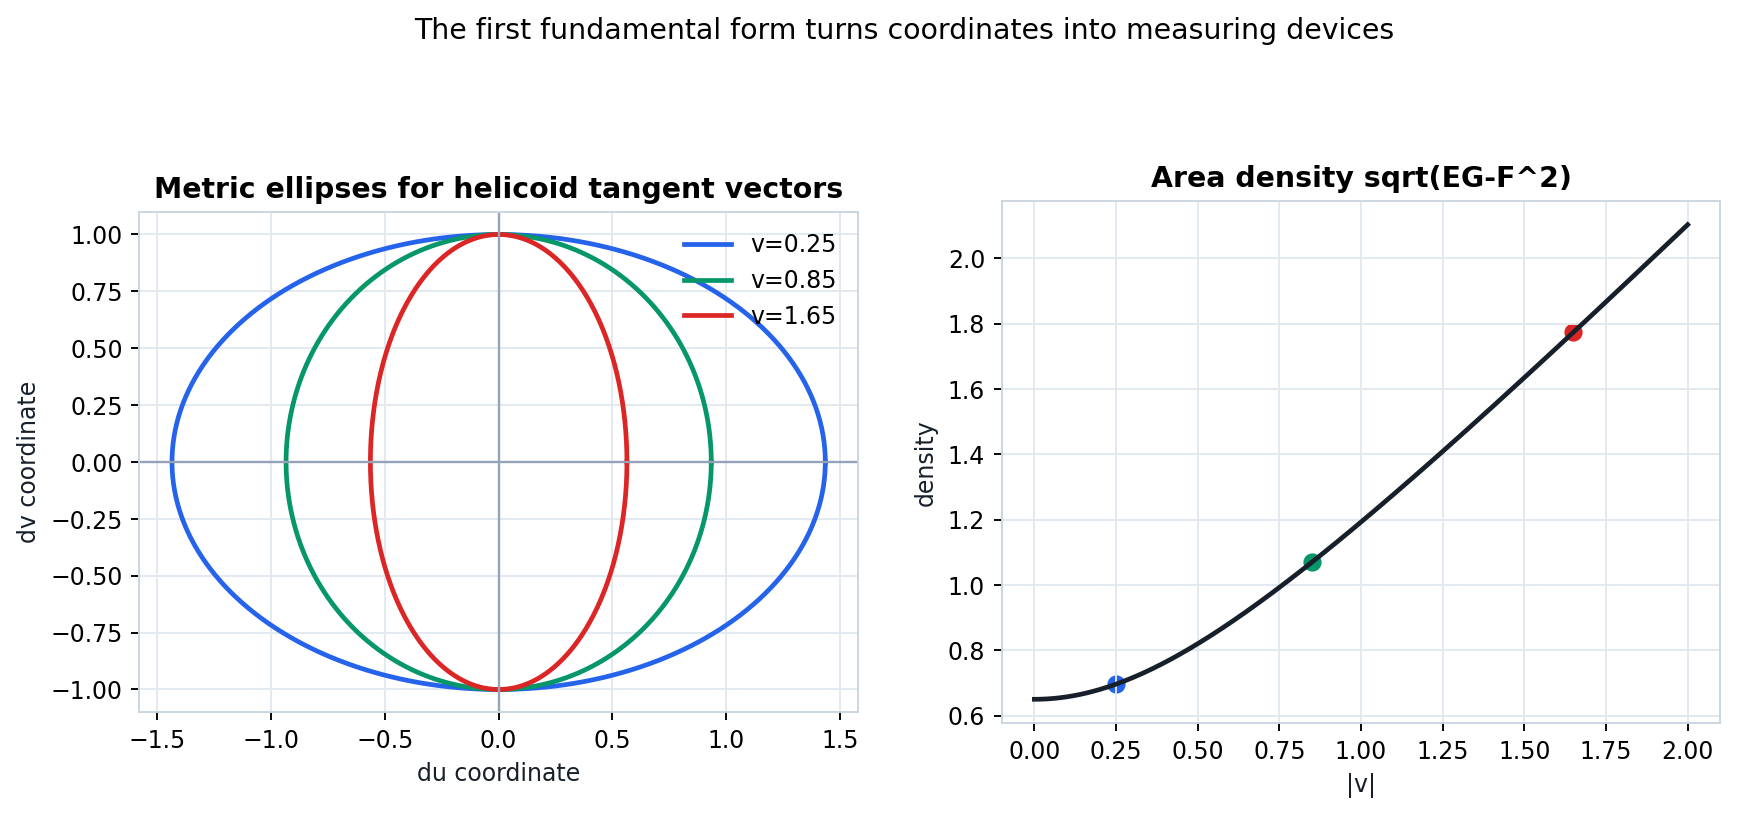

In [7]:
u, v, a = sp.symbols('u v a', positive=True, real=True)
X = sp.Matrix([v * sp.cos(u), v * sp.sin(u), a * u])
Xu = X.diff(u)
Xv = X.diff(v)
E = sp.simplify(Xu.dot(Xu))
F = sp.simplify(Xu.dot(Xv))
Gcoef = sp.simplify(Xv.dot(Xv))
metric_det = sp.simplify(E * Gcoef - F**2)
cross_norm_sq = sp.simplify((Xu.cross(Xv)).dot(Xu.cross(Xv)))
assert sp.simplify(metric_det - cross_norm_sq) == 0

pitch = 0.65
v_values = [0.25, 0.85, 1.65]
theta = np.linspace(0.0, 2.0 * np.pi, 420)
fig, axes = plt.subplots(1, 2, figsize=(12, 5.4))
for vv, color in zip(v_values, [COURSE_COLORS['blue'], COURSE_COLORS['green'], COURSE_COLORS['red']]):
    metric = np.array([[vv * vv + pitch * pitch, 0.0], [0.0, 1.0]])
    circle = np.column_stack([np.cos(theta), np.sin(theta)])
    transform = np.linalg.cholesky(np.linalg.inv(metric))
    ellipse = circle @ transform.T
    axes[0].plot(ellipse[:, 0], ellipse[:, 1], color=color, lw=2.0, label=f'v={vv:.2f}')
    axes[1].scatter([vv], [math.sqrt(vv * vv + pitch * pitch)], color=color, s=45)
axes[0].axhline(0, color='#94a3b8', lw=1)
axes[0].axvline(0, color='#94a3b8', lw=1)
axes[0].legend(loc='upper right')
finish_axes(axes[0], 'Metric ellipses for helicoid tangent vectors', 'du coordinate', 'dv coordinate')
axes[0].set_aspect('equal', adjustable='box')
vv_grid = np.linspace(0.0, 2.0, 300)
axes[1].plot(vv_grid, np.sqrt(vv_grid * vv_grid + pitch * pitch), color=COURSE_COLORS['ink'], lw=2.0)
finish_axes(axes[1], 'Area density sqrt(EG-F^2)', '|v|', 'density')
fig.suptitle('The first fundamental form turns coordinates into measuring devices')
save_fig('helicoid_metric_ellipses', 'first-fundamental-form-helicoid-ellipses.png', fig)
plt.close(fig)

metric_checks = {
    'symbolic_E': str(E),
    'symbolic_F': str(F),
    'symbolic_G': str(Gcoef),
    'symbolic_metric_det': str(metric_det),
    'cross_norm_identity_residual': str(sp.simplify(metric_det - cross_norm_sq)),
    'sample_metric_eigenvalues': [float(x) for x in np.linalg.eigvalsh(np.array([[1.2**2 + pitch**2, 0.0], [0.0, 1.0]]))],
}
CHECKS['first_fundamental_form'] = metric_checks
save_check('metric_identity_checks', 'first-fundamental-form-checks.json', metric_checks)
display_png('helicoid_metric_ellipses')


The same metric determinant is the local area scale. The helicoid view colors the surface by `sqrt(EG-F^2)`. The important inspection target is not the color palette; it is the fact that the density grows where the `u` coordinate curve sweeps a larger circle around the axis.


In [8]:
U = np.linspace(0.0, 2.0 * np.pi, 90)
V = np.linspace(-1.8, 1.8, 60)
Uh, Vh = np.meshgrid(U, V, indexing='ij')
Xh = Vh * np.cos(Uh)
Yh = Vh * np.sin(Uh)
Zh = pitch * Uh
area_density = np.sqrt(Vh * Vh + pitch * pitch)
fig = go.Figure()
fig.add_trace(go.Surface(x=Xh, y=Yh, z=Zh, surfacecolor=area_density, colorscale='Viridis', colorbar={'title': 'density'}, showscale=True, opacity=0.92))
fig.update_layout(
    title='Helicoid area density from the first fundamental form',
    scene={'aspectmode': 'data', 'xaxis_title': 'x', 'yaxis_title': 'y', 'zaxis_title': 'z'},
    margin={'l': 0, 'r': 0, 't': 48, 'b': 0})
save_html('helicoid_area_density', 'helicoid-area-density.html', fig)

helicoid_density_checks = {
    'density_min': float(area_density.min()),
    'density_max': float(area_density.max()),
    'density_centerline_value': float(pitch),
}
assert helicoid_density_checks['density_min'] >= pitch - 1e-12
CHECKS['helicoid_area_density'] = helicoid_density_checks
save_check('helicoid_area_density_checks', 'helicoid-area-density-checks.json', helicoid_density_checks)
display_html('helicoid_area_density')


## 5. Area: From Metric Determinants to Mesh Diagnostics

The area formula integrates the density `sqrt(EG-F^2)`. To keep that statement grounded, the next cell triangulates a torus with `trimesh`, computes mesh areas at increasing resolution, and compares them with the closed metric integral `4*pi^2*R*r`.

This is a mesh diagnostic, not a replacement for the formula. The mesh should converge toward the metric answer, and the periodic torus mesh should be watertight with Euler characteristic zero.


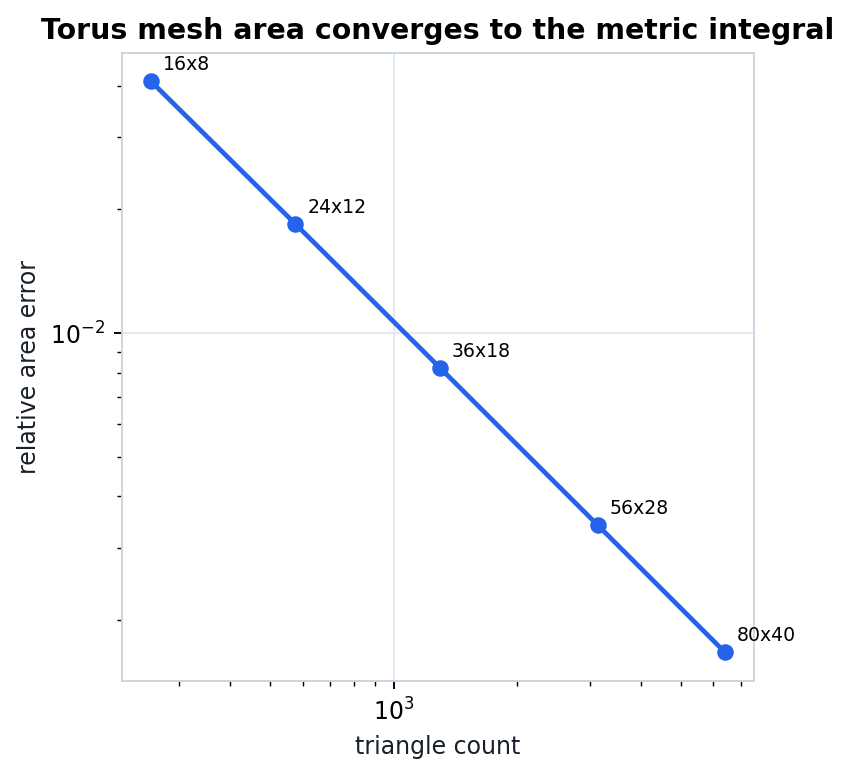

In [9]:
def torus_vertices_faces(major=1.6, minor=0.45, nu=48, nv=24):
    us = np.linspace(0.0, 2.0 * np.pi, nu, endpoint=False)
    vs = np.linspace(0.0, 2.0 * np.pi, nv, endpoint=False)
    U, V = np.meshgrid(us, vs, indexing='ij')
    X = (major + minor * np.cos(V)) * np.cos(U)
    Y = (major + minor * np.cos(V)) * np.sin(U)
    Z = minor * np.sin(V)
    vertices = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])
    faces = []
    for i in range(nu):
        ni = (i + 1) % nu
        for j in range(nv):
            nj = (j + 1) % nv
            p00 = i * nv + j
            p10 = ni * nv + j
            p11 = ni * nv + nj
            p01 = i * nv + nj
            faces.append([p00, p10, p11])
            faces.append([p00, p11, p01])
    return vertices, np.asarray(faces, dtype=int)

major = 1.6
minor = 0.45
analytic_torus_area = 4.0 * math.pi * math.pi * major * minor
resolutions = [(16, 8), (24, 12), (36, 18), (56, 28), (80, 40)]
area_rows = []
for nu_count, nv_count in resolutions:
    verts, faces = torus_vertices_faces(major, minor, nu_count, nv_count)
    mesh = trimesh.Trimesh(vertices=verts, faces=faces, process=False)
    area_rows.append({
        'nu': nu_count,
        'nv': nv_count,
        'vertices': int(len(verts)),
        'faces': int(len(faces)),
        'mesh_area': float(mesh.area),
        'relative_error': float(abs(mesh.area - analytic_torus_area) / analytic_torus_area),
        'euler_number': int(mesh.euler_number),
        'is_watertight': bool(mesh.is_watertight),
    })

csv_path = TABLE_DIR / 'torus-area-mesh-refinement.csv'
with csv_path.open('w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=list(area_rows[0].keys()))
    writer.writeheader()
    writer.writerows(area_rows)
register('torus_area_table', csv_path)

fig, ax = plt.subplots(figsize=(7.2, 4.8))
face_counts = [row['faces'] for row in area_rows]
rel_errors = [row['relative_error'] for row in area_rows]
ax.loglog(face_counts, rel_errors, marker='o', color=COURSE_COLORS['blue'], lw=2.0)
for row in area_rows:
    ax.annotate(f"{row['nu']}x{row['nv']}", (row['faces'], row['relative_error']), textcoords='offset points', xytext=(5, 5), fontsize=8)
finish_axes(ax, 'Torus mesh area converges to the metric integral', 'triangle count', 'relative area error')
save_fig('torus_area_refinement', 'torus-area-mesh-refinement.png', fig)
plt.close(fig)

torus_area_checks = {
    'analytic_area': float(analytic_torus_area),
    'rows': area_rows,
    'last_relative_error': float(area_rows[-1]['relative_error']),
    'last_euler_number': int(area_rows[-1]['euler_number']),
    'last_is_watertight': bool(area_rows[-1]['is_watertight']),
}
assert torus_area_checks['last_relative_error'] < 0.004
assert torus_area_checks['last_euler_number'] == 0
assert torus_area_checks['last_is_watertight'] is True
CHECKS['torus_mesh_area'] = torus_area_checks
save_check('torus_area_checks', 'torus-area-mesh-checks.json', torus_area_checks)
display_png('torus_area_refinement')


## 6. Orientation: Local Normals Versus Global Compatibility

Every regular surface is locally orientable: a patch gives a normal from `x_u cross x_v`. Orientability asks whether those local choices can be made compatible across the whole surface.

The torus has a coherent outward normal field. The open Mobius band is the warning example: following a normal around the centerline returns to the same point with the opposite normal. The plot uses samples away from the boundary; the check is the dot product after one full circuit.


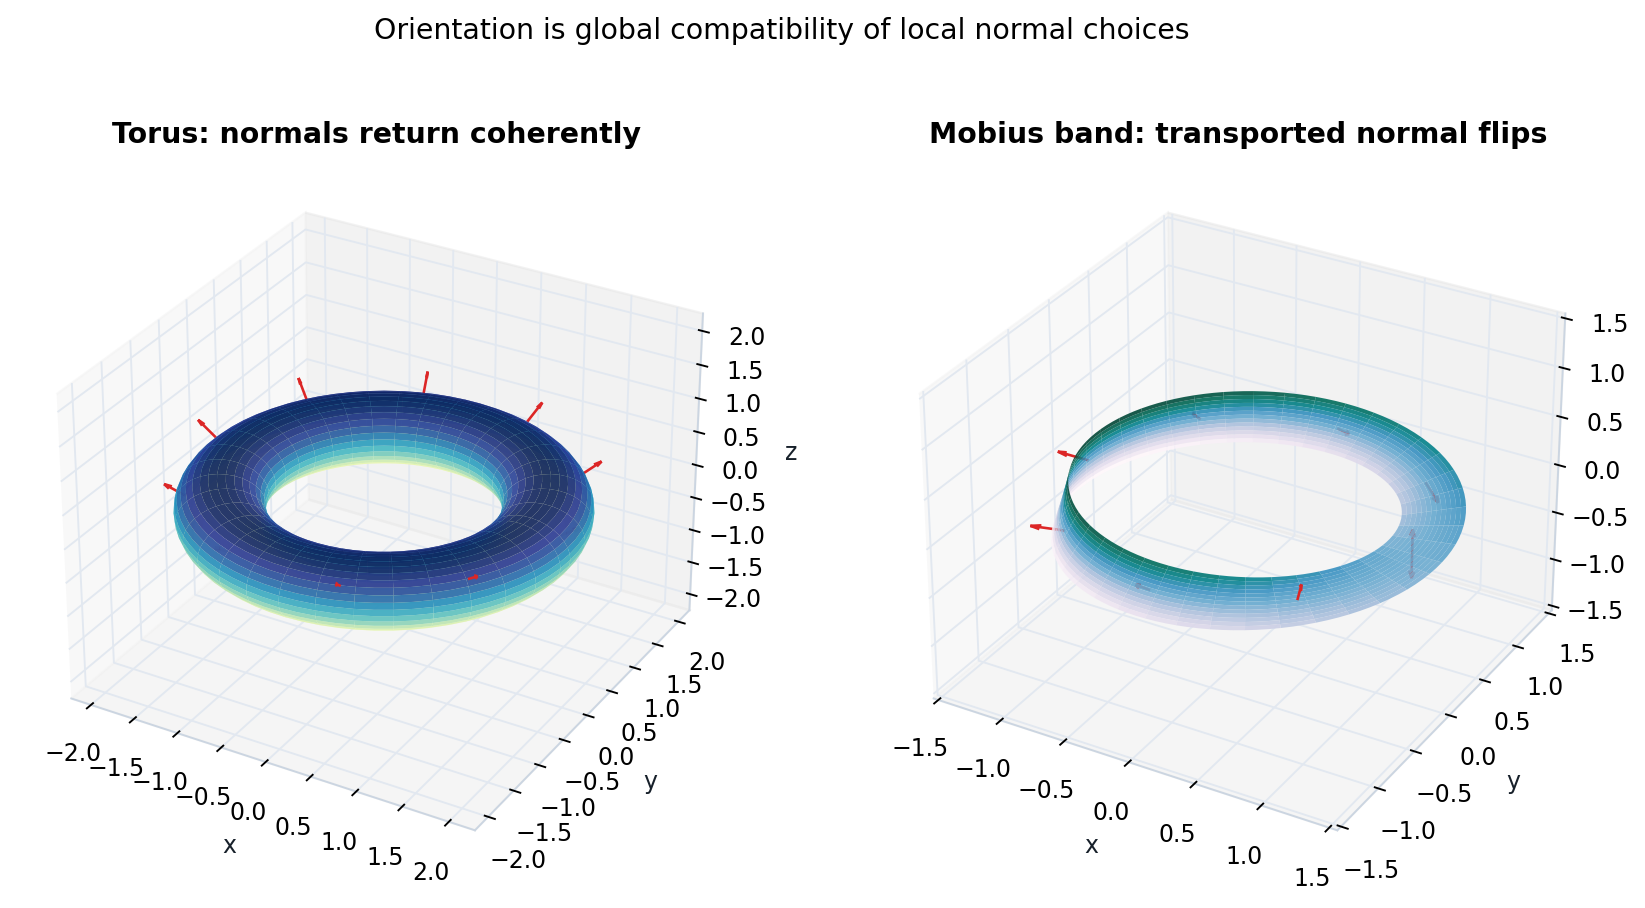

In [10]:
def torus_point_normal(u, v, major=1.6, minor=0.45):
    point = np.array([(major + minor * np.cos(v)) * np.cos(u), (major + minor * np.cos(v)) * np.sin(u), minor * np.sin(v)])
    normal = np.array([np.cos(v) * np.cos(u), np.cos(v) * np.sin(u), np.sin(v)])
    return point, normal / np.linalg.norm(normal)


def mobius_point(u, s, radius=1.25):
    return np.array([
        (radius + s * np.cos(u / 2.0)) * np.cos(u),
        (radius + s * np.cos(u / 2.0)) * np.sin(u),
        s * np.sin(u / 2.0),
    ])


def mobius_normal(u, s):
    eps = 1e-5
    xu = (mobius_point(u + eps, s) - mobius_point(u - eps, s)) / (2 * eps)
    xs = (mobius_point(u, s + eps) - mobius_point(u, s - eps)) / (2 * eps)
    n = np.cross(xu, xs)
    return n / np.linalg.norm(n)

# Build surfaces for display.
tu = np.linspace(0.0, 2.0 * np.pi, 70)
tv = np.linspace(0.0, 2.0 * np.pi, 34)
TU, TV = np.meshgrid(tu, tv, indexing='ij')
TX = (major + minor * np.cos(TV)) * np.cos(TU)
TY = (major + minor * np.cos(TV)) * np.sin(TU)
TZ = minor * np.sin(TV)

mu = np.linspace(0.0, 2.0 * np.pi, 120)
ms = np.linspace(-0.22, 0.22, 14)
MU, MS = np.meshgrid(mu, ms, indexing='ij')
MX = (1.25 + MS * np.cos(MU / 2.0)) * np.cos(MU)
MY = (1.25 + MS * np.cos(MU / 2.0)) * np.sin(MU)
MZ = MS * np.sin(MU / 2.0)

fig = plt.figure(figsize=(12, 5.6))
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(TX, TY, TZ, cmap='YlGnBu', linewidth=0, antialiased=True, alpha=0.88)
for uu in np.linspace(0.0, 2.0 * np.pi, 10, endpoint=False):
    p_t, n_t = torus_point_normal(uu, 0.75, major, minor)
    ax1.quiver(*p_t, *(0.28 * n_t), color=COURSE_COLORS['red'], linewidth=1.1)
ax1.set_title('Torus: normals return coherently')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')
equalize_3d_axes(ax1, TX.ravel(), TY.ravel(), TZ.ravel())

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(MX, MY, MZ, cmap='PuBuGn', linewidth=0, antialiased=True, alpha=0.9)
for uu in np.linspace(0.0, 2.0 * np.pi, 9):
    p_m = mobius_point(uu, 0.0)
    n_m = mobius_normal(uu, 0.0)
    ax2.quiver(*p_m, *(0.25 * n_m), color=COURSE_COLORS['red'], linewidth=1.1)
ax2.set_title('Mobius band: transported normal flips')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('z')
equalize_3d_axes(ax2, MX.ravel(), MY.ravel(), MZ.ravel())
fig.suptitle('Orientation is global compatibility of local normal choices', y=1.02)
save_fig('orientation_coherence', 'orientation-normal-coherence.png', fig)
plt.close(fig)

p0, n0 = torus_point_normal(0.0, 0.75, major, minor)
p1, n1 = torus_point_normal(2.0 * np.pi, 0.75, major, minor)
m0 = mobius_normal(0.0, 0.0)
m1 = mobius_normal(2.0 * np.pi, 0.0)
orientation_checks = {
    'torus_return_point_error': float(np.linalg.norm(p1 - p0)),
    'torus_return_normal_dot': float(np.dot(n0, n1)),
    'mobius_return_point_error': float(np.linalg.norm(mobius_point(2.0 * np.pi, 0.0) - mobius_point(0.0, 0.0))),
    'mobius_return_normal_dot': float(np.dot(m0, m1)),
}
assert orientation_checks['torus_return_point_error'] < 1e-12
assert orientation_checks['torus_return_normal_dot'] > 0.999999
assert orientation_checks['mobius_return_point_error'] < 1e-12
assert orientation_checks['mobius_return_normal_dot'] < -0.999
CHECKS['orientation'] = orientation_checks
save_check('orientation_checks', 'orientation-normal-checks.json', orientation_checks)
display_png('orientation_coherence')


## Applied Lab: Design a Regular Helicoid Patch and Audit Its Area

The lab changes one geometric parameter, the helicoid pitch `a`. For the patch

`x(u,v) = (v cos u, v sin u, a u)` on `0 <= u <= 2*pi`, `-b <= v <= b`,

the metric determinant gives area density `sqrt(v^2 + a^2)`. Increase `a` and the surface opens in the vertical direction; the area should increase even though the parameter rectangle is unchanged.

To extend the lab, change `pitch_values` or `half_width`, rerun the cell, and decide which rank, metric, and area checks should still pass.


In [11]:
def helicoid_patch_area(pitch_value, half_width):
    return 2.0 * math.pi * (half_width * math.sqrt(half_width * half_width + pitch_value * pitch_value) + pitch_value * pitch_value * math.asinh(half_width / pitch_value))

pitch_values = [0.25, 0.55, 0.95, 1.35]
half_width = 1.4
lab_rows = []
for pitch_value in pitch_values:
    min_density = pitch_value
    max_density = math.sqrt(half_width * half_width + pitch_value * pitch_value)
    area_value = helicoid_patch_area(pitch_value, half_width)
    lab_rows.append({
        'pitch': pitch_value,
        'min_density': min_density,
        'max_density': max_density,
        'area': area_value,
    })

lab_csv = TABLE_DIR / 'applied-helicoid-pitch-sweep.csv'
with lab_csv.open('w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=list(lab_rows[0].keys()))
    writer.writeheader()
    writer.writerows(lab_rows)
register('applied_lab_table', lab_csv)

lab_checks = {
    'half_width': half_width,
    'pitch_values': pitch_values,
    'areas': [float(row['area']) for row in lab_rows],
    'area_strictly_increases_with_pitch': bool(np.all(np.diff([row['area'] for row in lab_rows]) > 0)),
    'density_min_equals_pitch': bool(all(abs(row['min_density'] - row['pitch']) < 1e-12 for row in lab_rows)),
}
assert lab_checks['area_strictly_increases_with_pitch'] is True
assert lab_checks['density_min_equals_pitch'] is True
CHECKS['applied_lab'] = lab_checks
save_check('applied_lab_checks', 'applied-helicoid-lab-checks.json', lab_checks)
lab_rows


[{'pitch': 0.25,
  'min_density': 0.25,
  'max_density': 1.4221462653327892,
  'area': 13.461672836344516},
 {'pitch': 0.55,
  'min_density': 0.55,
  'max_density': 1.5041608956491324,
  'area': 16.393959290734564},
 {'pitch': 0.95,
  'min_density': 0.95,
  'max_density': 1.691892431568863,
  'area': 21.574375893014548},
 {'pitch': 1.35,
  'min_density': 1.35,
  'max_density': 1.9448650338776723,
  'area': 27.497763216652174}]

## Final Sanity Checks

The last cell checks the mathematical identities and the file artifacts together. A passing run means the notebook has regenerated the chapter visuals, the artifacts exist with nonzero size, and the core rank, regular-value, tangent, metric, area, and orientation invariants survived execution.


In [12]:
# Reassert the core mathematical checks in one place.
assert CHECKS['regularity']['graph_cross_norm_min'] > 0.99
assert CHECKS['regularity']['cone_cross_norm_at_apex'] == 0.0
assert CHECKS['regular_value']['gradient_norm_min'] > 1.35
assert CHECKS['coordinate_change']['min_abs_det_sample'] > 0.0
assert abs(CHECKS['tangent_differential']['p_dot_w']) < 1e-14
assert abs(CHECKS['tangent_differential']['rotated_p_dot_rotated_w']) < 1e-14
assert CHECKS['first_fundamental_form']['cross_norm_identity_residual'] == '0'
assert CHECKS['torus_mesh_area']['last_relative_error'] < 0.004
assert CHECKS['torus_mesh_area']['last_euler_number'] == 0
assert CHECKS['orientation']['mobius_return_normal_dot'] < -0.999
assert CHECKS['applied_lab']['area_strictly_increases_with_pitch'] is True

final_path = CHECK_DIR / 'final-sanity.json'
register('final_sanity', final_path)
artifact_sizes = {}
for key, rel_path in sorted(PATHS.items()):
    if key == 'final_sanity':
        continue
    full_path = BOOK_ROOT / rel_path
    min_bytes = 64 if full_path.suffix.lower() in {'.json', '.csv'} else 512
    artifact_sizes[key] = assert_artifact(full_path, min_bytes=min_bytes).stat().st_size

final_sanity = {
    'unit': UNIT,
    'source_span': SOURCE_SPAN,
    'artifact_count_excluding_final_sanity': len(artifact_sizes),
    'artifact_sizes': artifact_sizes,
    'paths': PATHS,
    'checks': CHECKS,
}
final_path.write_text(json.dumps(final_sanity, indent=2, sort_keys=True), encoding='utf-8')
artifact_sizes['final_sanity'] = assert_artifact(final_path, min_bytes=512).stat().st_size
final_sanity['artifact_sizes'] = artifact_sizes
final_sanity['artifact_count_including_final_sanity'] = len(artifact_sizes)
final_path.write_text(json.dumps(final_sanity, indent=2, sort_keys=True), encoding='utf-8')
assert_artifact(final_path, min_bytes=512)
final_sanity


{'unit': 'chapter-02',
 'source_span': {'printed_pages': '53-135',
  'pdf_pages': '69-151',
  'source_map': 'pdf_page = printed_page + 16',
  'sections': ['2-1 introduction',
   '2-2 regular surfaces and regular values',
   '2-3 chart changes and differentiable functions',
   '2-4 tangent planes and differentials',
   '2-5 first fundamental form and area',
   '2-6 orientation',
   '2-7 compact orientable surfaces',
   '2-8 geometric area',
   'appendix: continuity and differentiability']},
 'artifact_count_excluding_final_sanity': 20,
 'artifact_sizes': {'applied_lab_checks': 298,
  'applied_lab_table': 231,
  'coordinate_change_checks': 205,
  'helicoid_area_density': 298595,
  'helicoid_area_density_checks': 116,
  'helicoid_metric_ellipses': 146668,
  'metric_identity_checks': 222,
  'orientation_checks': 184,
  'orientation_coherence': 375245,
  'regular_value_checks': 154,
  'regular_value_ellipsoid': 228652,
  'regularity_checks': 203,
  'regularity_rank': 394448,
  'stereographi

## Takeaways

A regular surface is a local two-dimensional object with certificates. Patches need rank two, regular values need nonzero gradient, and chart changes need nonsingular Jacobians. Tangent vectors can be defined by surface curves, but a patch basis gives a practical coordinate language for them. The first fundamental form is the bridge from local linear algebra to lengths, angles, and area. Orientation looks local when normal arrows are drawn in one chart, but the Mobius check shows why global compatibility is a separate question.
